<a href="https://colab.research.google.com/github/omar192501/superstore_analysis/blob/main/superstore_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
df=pd.read_csv('/content/drive/MyDrive/csv_files/superstore.csv')
df

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,Office Supplies,Los Angeles,United States,AM-103604,Alice McCarthy,0.2,US,1,2014-12-03 00:00:00.000,CA-2014-109701,...,69,Corporate,2014-12-04 00:00:00.000,Same Day,5.15,California,Binders,2014,North America,49
51286,Office Supplies,Los Angeles,United States,AM-103604,Alice McCarthy,0.2,US,1,2014-12-03 00:00:00.000,CA-2014-109701,...,9,Corporate,2014-12-04 00:00:00.000,Same Day,0.44,California,Binders,2014,North America,49
51287,Office Supplies,Los Angeles,United States,HR-147704,Hallie Redmond,0.2,US,1,2014-12-18 00:00:00.000,CA-2014-106964,...,12,Home Office,2014-12-21 00:00:00.000,First Class,0.31,California,Binders,2014,North America,51
51288,Office Supplies,Los Angeles,United States,RM-196754,Robert Marley,0.2,US,1,2014-12-25 00:00:00.000,CA-2014-145219,...,90,Home Office,2014-12-26 00:00:00.000,First Class,15.95,California,Binders,2014,North America,52


In [34]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null 

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', '记录数', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID',
       'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State',
       'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')

In [35]:
df.describe()

,Discount,记录数,Profit,Quantity,Row.ID,Sales,Shipping.Cost,Year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,0.0,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,1.0,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


In [36]:
categorial=df.dtypes[df.dtypes=='object'].index
df[categorial].describe()

,Category,City,Country,Customer.ID,Customer.Name,Market,Order.Date,Order.ID,Order.Priority,Product.ID,Product.Name,Region,Segment,Ship.Date,Ship.Mode,State,Sub.Category,Market2
count,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290
unique,3,3636,147,4873,795,7,1430,25035,4,10292,3788,13,3,1464,4,1094,17,6
top,Office Supplies,New York City,United States,JG-158051,Muhammed Yedwab,APAC,2014-06-18 00:00:00.000,CA-2014-100111,Medium,OFF-AR-10003651,Staples,Central,Consumer,2014-11-22 00:00:00.000,Standard Class,California,Binders,APAC
freq,31273,915,9994,40,108,11002,135,14,29433,35,227,11117,26518,130,30775,2001,6152,11002


In [37]:
df['Order.Date']=pd.to_datetime(df['Order.Date'])
df['Ship.Date']=pd.to_datetime(df['Ship.Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Category        51290 non-null  object        
 1   City            51290 non-null  object        
 2   Country         51290 non-null  object        
 3   Customer.ID     51290 non-null  object        
 4   Customer.Name   51290 non-null  object        
 5   Discount        51290 non-null  float64       
 6   Market          51290 non-null  object        
 7   记录数             51290 non-null  int64         
 8   Order.Date      51290 non-null  datetime64[ns]
 9   Order.ID        51290 non-null  object        
 10  Order.Priority  51290 non-null  object        
 11  Product.ID      51290 non-null  object        
 12  Product.Name    51290 non-null  object        
 13  Profit          51290 non-null  float64       
 14  Quantity        51290 non-null  int64         
 15  Re

In [38]:
df.isnull().sum()

,0
Category,0
City,0
Country,0
Customer.ID,0
Customer.Name,0
Discount,0
Market,0
记录数,0
Order.Date,0
Order.ID,0


In [39]:
df['Region'].value_counts()

,count
Region,
Central,11117
South,6645
EMEA,5029
North,4785
Africa,4587
Oceania,3487
West,3203
Southeast Asia,3129
East,2848


In [40]:
profit_per_country=df.groupby('Country')['Profit'].sum().sort_values()
display(profit_per_country)
print((df['Profit']<0).sum())

,Profit
Country,
Turkey,-98447.2320
Nigeria,-80750.7180
Netherlands,-41070.0750
Honduras,-29482.3714
Pakistan,-22446.6480
...,...
France,109029.0030
United Kingdom,111900.1500
India,129071.8350


12544


In [41]:
loss_countries = profit_per_country[profit_per_country < 0].index
df_loss = df[df['Country'].isin(loss_countries)]
df_loss.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
29302,Furniture,Sivas,Turkey,PA-90602,Pete Armstrong,0.6,EMEA,1,2011-04-25,TU-2011-7670,...,46,Home Office,2011-04-30,Second Class,3.07,Sivas,Chairs,2011,EMEA,18
29303,Technology,Ankara,Turkey,LC-69602,Lindsay Castell,0.6,EMEA,1,2011-04-26,TU-2011-3910,...,413,Home Office,2011-04-29,Second Class,61.42,Ankara,Accessories,2011,EMEA,18
29304,Technology,Kartal,Turkey,CG-20402,Catherine Glotzbach,0.6,EMEA,1,2011-07-15,TU-2011-9120,...,141,Home Office,2011-07-18,First Class,42.89,Istanbul,Phones,2011,EMEA,29
29305,Furniture,Gebze,Turkey,PR-88803,Patrick Ryan,0.6,EMEA,1,2011-07-16,TU-2011-490,...,268,Consumer,2011-07-19,Second Class,60.35,Kocaeli,Tables,2011,EMEA,29
29306,Furniture,Istanbul,Turkey,MY-82952,Muhammed Yedwab,0.6,EMEA,1,2011-08-17,TU-2011-660,...,579,Corporate,2011-08-19,First Class,116.87,Istanbul,Bookcases,2011,EMEA,34


In [42]:
df_loss.corr(numeric_only=True)['Profit'].sort_values()

,Profit
Sales,-0.425627
Shipping.Cost,-0.369754
Discount,-0.242086
Quantity,-0.207045
Row.ID,-0.097064
weeknum,0.006712
Year,0.008472
Profit,1.000000
记录数,NaN


In [43]:
df_loss.groupby('Country')['Discount'].mean().sort_values()

,Discount
Country,
Myanmar (Burma),0.236176
Vietnam,0.239434
Dominican Republic,0.242563
Philippines,0.345888
Thailand,0.362542
Panama,0.406299
Honduras,0.406833
Peru,0.407457
Venezuela,0.409412


In [44]:
high_discount = df_loss[df_loss['Discount'] > 0.2]['Profit']
low_discount = df_loss[df_loss['Discount'] <= 0.2]['Profit']
ttest_ind(high_discount, low_discount)

TtestResult(statistic=np.float64(-15.993383359772906), pvalue=np.float64(1.0653704829664591e-56), df=np.float64(8013.0))

In [45]:
df_loss.groupby(pd.cut(df_loss['Discount'], bins=3))['Profit'].mean()

/tmp/ipykernel_18936/2523000156.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_loss.groupby(pd.cut(df_loss['Discount'], bins=3))['Profit'].mean()


,Profit
Discount,
"(0.149, 0.367]",8.238123
"(0.367, 0.583]",-56.021449
"(0.583, 0.8]",-91.389513


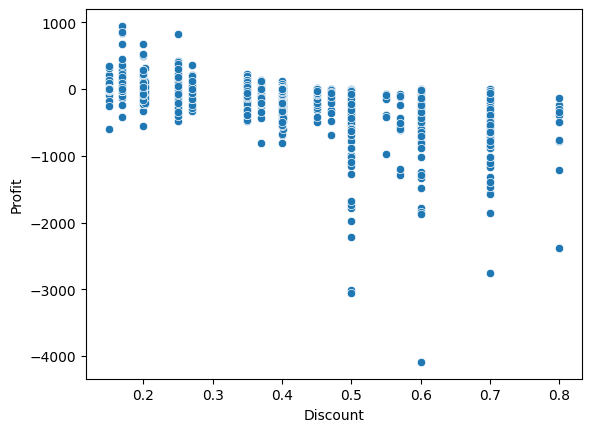

In [46]:
sns.scatterplot(data=df_loss, x='Discount', y='Profit')
plt.show()

In [47]:
df_loss.groupby('Country')[['Sales','Profit']].mean()

,Sales,Profit
Country,,
Argentina,147.461538,-47.932812
Denmark,132.969231,-65.877646
Dominican Republic,169.995957,-10.260780
Haiti,106.115385,-40.262606
Honduras,126.419355,-41.349750
Ireland,156.962264,-69.739443
Kazakhstan,45.564356,-70.296000
Lithuania,134.460000,-179.322360
Myanmar (Burma),251.058824,-15.509252


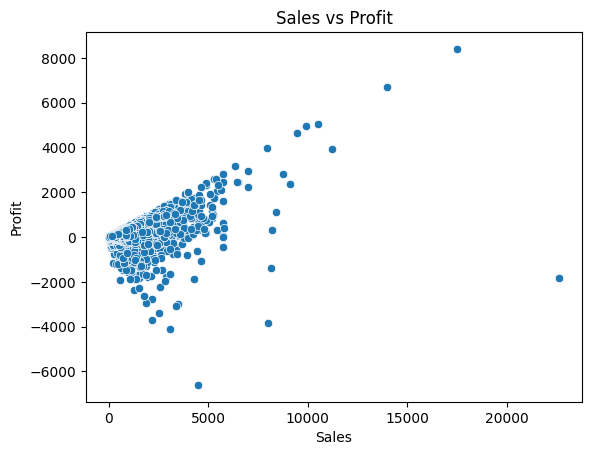

In [48]:
sns.scatterplot(data=df, x='Sales', y='Profit')
plt.title("Sales vs Profit")
plt.show()

In [49]:
df_loss['Profit_Margin'] = df_loss['Profit'] / df_loss['Sales']
df_loss[['Sales','Profit','Profit_Margin']].head()

/tmp/ipykernel_18936/4206192524.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_loss['Profit_Margin'] = df_loss['Profit'] / df_loss['Sales']


,Sales,Profit,Profit_Margin
29302,46,-43.956,-0.955565
29303,413,-392.040,-0.949249
29304,141,-119.844,-0.849957
29305,268,-127.308,-0.475030
29306,579,-361.944,-0.625119


In [50]:
df_loss.groupby(pd.cut(df_loss['Shipping.Cost'], bins=3))['Profit'].mean()

/tmp/ipykernel_18936/1173522321.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_loss.groupby(pd.cut(df_loss['Shipping.Cost'], bins=3))['Profit'].mean()


,Profit
Shipping.Cost,
"(-0.684, 234.699]",-53.763154
"(234.699, 469.377]",-439.063397
"(469.377, 704.056]",-600.139240


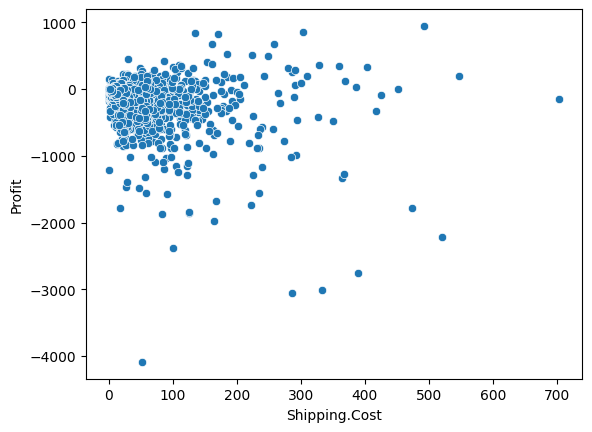

In [51]:
sns.scatterplot(data=df_loss,x='Shipping.Cost', y='Profit')
plt.show()

In [52]:
df_loss.sort_values(by='Profit_Margin')[['Shipping.Cost','Discount','Sales','Profit','Profit_Margin']].head()

,Shipping.Cost,Discount,Sales,Profit,Profit_Margin
34880,6.07,0.8,63,-244.386,-3.879143
35832,14.94,0.8,127,-488.772,-3.848598
37972,9.62,0.8,108,-390.264,-3.613556
40395,7.72,0.8,100,-344.412,-3.444120
40378,0.25,0.8,375,-1218.384,-3.249024


In [53]:
df_opt=df_loss.copy()

In [54]:
df_opt['opt_discount']=df_opt['Discount'].apply(lambda x:min(x,0.2))
df_opt['opt_shipping']=df_opt['Shipping.Cost']*0.8
df_opt['Opt_Profit'] = (
    df_opt['Sales'] * (1 - df_opt['opt_discount'])
    - df_opt['opt_shipping']
)

In [55]:
df_opt.groupby('Country')[['Profit','Opt_Profit']].mean()

,Profit,Opt_Profit
Country,,
Argentina,-47.932812,104.910027
Denmark,-65.877646,95.469415
Dominican Republic,-10.260780,120.268391
Haiti,-40.262606,74.718823
Honduras,-41.349750,90.283886
Ireland,-69.739443,110.345208
Kazakhstan,-70.296000,32.473109
Lithuania,-179.322360,91.673120
Myanmar (Burma),-15.509252,186.674941
